# Customer Support Triage — Model Training

This notebook trains and evaluates machine learning models for automatically
classifying customer support tickets.

The project predicts three attributes:

- **Type** — Incident, Request, Problem, or Change
- **Priority** — Low, Medium, or High
- **Queue** — The support team responsible for handling the ticket

A TF-IDF + Logistic Regression model will first be developed as a baseline.
The baseline will later be compared with a fine-tuned DistilBERT model.

The training, validation, and test datasets were created using a
group-based split on `clean_text` to prevent identical ticket text from
appearing across different splits.

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (19768, 7)
Validation: (4226, 7)
Test: (4267, 7)


In [3]:
print(train_df.columns.tolist())

['subject', 'body', 'type', 'priority', 'queue', 'text', 'clean_text']


## 1. TF-IDF Feature Extraction

Machine learning models such as Logistic Regression cannot directly work with
raw text. Therefore, the ticket text must first be converted into numerical
features.

TF-IDF (Term Frequency-Inverse Document Frequency) represents each ticket as a
numerical vector based on the importance of words in the dataset.

The vectorizer is fitted only on the training data. Validation and test data are
transformed using the vocabulary learned from the training data to prevent
information leakage.

In [4]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [5]:
X_train = vectorizer.fit_transform(train_df["clean_text"])

X_val = vectorizer.transform(val_df["clean_text"])

X_test = vectorizer.transform(test_df["clean_text"])

## 2. Type Classification

The first classification task is to predict the `type` of a customer support ticket.

The target contains four classes:

- Incident
- Request
- Problem
- Change

The TF-IDF features created from `clean_text` will be used as input to a
Logistic Regression classifier.

In [6]:
y_train = train_df["type"]
y_val = val_df["type"]
y_test = test_df["type"]

In [7]:
print(y_train.value_counts())

type
Incident    7855
Request     5704
Problem     4127
Change      2082
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression

model_type = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [9]:
model_type.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [10]:
y_val_pred = model_type.predict(X_val)

In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8561287269285376
              precision    recall  f1-score   support

      Change       0.99      0.94      0.96       472
    Incident       0.78      0.91      0.84      1660
     Problem       0.75      0.52      0.62       875
     Request       0.98      0.99      0.99      1219

    accuracy                           0.86      4226
   macro avg       0.87      0.84      0.85      4226
weighted avg       0.85      0.86      0.85      4226



## Confusion Matrix

The confusion matrix is used to understand the classification errors made by the model. It compares the actual ticket types with the types predicted by the model.

This helps identify which ticket categories are being confused with each other.

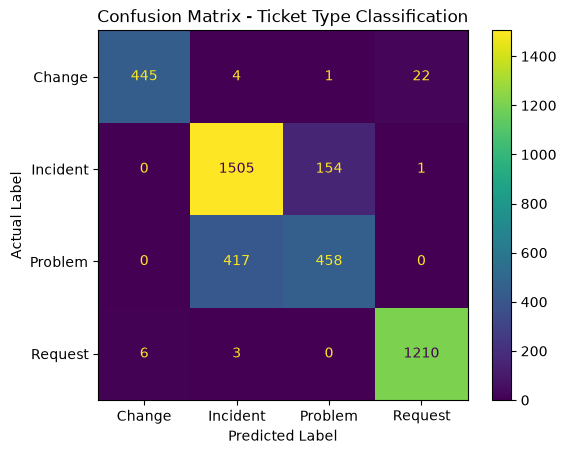

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_type.classes_
)

disp.plot()

plt.title("Confusion Matrix - Ticket Type Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Confusion Matrix Analysis

The confusion matrix provides a detailed view of the classification performance across the four ticket types: Change, Incident, Problem, and Request.

The model performs well on Change and Request tickets, with most samples correctly classified along the diagonal of the confusion matrix.

The major source of error is the distinction between Incident and Problem tickets. In particular, 417 actual Problem tickets were incorrectly classified as Incident, while 154 Incident tickets were classified as Problem.

This explains the relatively low recall of 0.52 for the Problem class observed in the classification report. The model is able to identify only about half of the actual Problem tickets.

The confusion matrix indicates that the TF-IDF and Logistic Regression baseline has difficulty distinguishing semantically similar Incident and Problem tickets. This suggests that further model improvement may be necessary, potentially through feature engineering, hyperparameter tuning, or a more context-aware NLP model such as DistilBERT.

## Error Analysis

The confusion matrix showed that the largest classification error occurs between the `Problem` and `Incident` classes.

In this section, we examine incorrectly classified validation tickets to understand why the baseline model confuses these categories.

In [15]:
problem_as_incident = val_df[
    (y_val == "Problem") &
    (y_val_pred == "Incident")
]

print("Problem tickets predicted as Incident:",
      len(problem_as_incident))

Problem tickets predicted as Incident: 417


In [17]:
problem_as_incident = problem_as_incident.copy()

problem_as_incident["predicted_type"] = y_val_pred[
    problem_as_incident.index
]

problem_as_incident[
    ["subject", "type", "predicted_type", "priority", "queue"]
].head(20)

,subject,type,predicted_type,priority,queue
13,Difficulty Connecting VR Controller,Problem,Incident,medium,Technical Support
33,Urgent Discrepancy in Billing: Invoice Reconci...,Problem,Incident,medium,Billing and Payments
64,Immediate Help Required for SaaS Platform Problem,Problem,Incident,medium,Technical Support
65,Immediate Help Needed for Stability Concerns o...,Problem,Incident,medium,Product Support
72,Critical Wi-Fi Connectivity Disruption Issue,Problem,Incident,high,Service Outages and Maintenance
83,Performance Concerns with Cloud SaaS Solution,Problem,Incident,medium,Technical Support
88,Problems with Integrations,Problem,Incident,high,Customer Service
91,Request for Financial Assistance,Problem,Incident,medium,Technical Support
95,Billing Discrepancies Reported by Financial In...,Problem,Incident,high,Billing and Payments
112,NaN,Problem,Incident,medium,IT Support


In [21]:
problem_as_incident[
    ["clean_text", "type", "predicted_type"]
].head(10).to_string(index=False)

"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            clean_text    type predicted_type\n                                                                        difficulty connecting vr controller dear support team, i hope this message reaches you well. i am reaching out for help regarding an issue with my vr controller. recently, i have been unable t

In [22]:
problem_as_incident["clean_text"].head()

13    difficulty connecting vr controller dear suppo...
33    urgent discrepancy in billing: invoice reconci...
64    immediate help required for saas platform prob...
65    immediate help needed for stability concerns o...
72    critical wi-fi connectivity disruption issue d...
Name: clean_text, dtype: str

In [23]:
print(problem_as_incident["clean_text"].isna().sum())
print(problem_as_incident["clean_text"].str.strip().eq("").sum())

0
0


In [24]:
for i in problem_as_incident.index[:10]:
    print("=" * 100)
    print("INDEX:", i)
    print(problem_as_incident.loc[i, "clean_text"])

INDEX: 13
difficulty connecting vr controller dear support team, i hope this message reaches you well. i am reaching out for help regarding an issue with my vr controller. recently, i have been unable to synchronize the controller with my headset. despite trying multiple times, the device does not seem to connect or sync correctly. i have attempted various troubleshooting methods, including restarting both the headset and controller, verifying firmware updates, and ensuring that the batteries are fully charged. regrettably, none of these actions have resolved the issue. the controller simply appears in the list without pairing successfully.
INDEX: 33
urgent discrepancy in billing: invoice reconciliation services dear customer support team, i am reaching out to highlight a billing inconsistency found in recent payment records. the billed amount matches the services rendered. after a thorough review of the invoices and cross-checking with service logs, the issue remains unresolved. it se

In [26]:
correct_problems = val_df[
    (y_val == "Problem") &
    (y_val_pred == "Problem")
]

print("Correctly predicted Problems:", len(correct_problems))

Correctly predicted Problems: 458


In [27]:
for i in correct_problems.index[:10]:
    print("=" * 100)
    print("INDEX:", i)
    print(correct_problems.loc[i, "clean_text"])

INDEX: 6
problem report customer support, i am facing difficulties with the centralized account administration process. although the features seem to be functioning normally, there are delays and confusion when handling several accounts simultaneously. could you kindly look into this matter and offer advice on how to fix it? your prompt help would be highly valued. thanks for your support. best regards, [your name]
INDEX: 17
synchronization problem dear customer support, i am encountering difficulties with multiple smart devices across various departments where their software systems are not syncing data correctly. the issue appears to originate from integration problems with different applications used by iot devices. despite trying standard troubleshooting measures such as rebooting devices and updating firmware to the latest versions, the problem remains unresolved. could you please assist in diagnosing and resolving these synchronization issues? ensuring smooth operation is essenti

In [31]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

for i, class_name in enumerate(model_type.classes_):
    top_indices = np.argsort(model_type.coef_[i])[-15:][::-1]

    print("\n" + "=" * 50)
    print(f"Top features for: {class_name}")
    print("=" * 50)

    for idx in top_indices:
        print(feature_names[idx], round(model_type.coef_[i][idx], 3))


Top features for: Change
update 4.592
improve 4.571
enhance 3.96
request 3.569
and 3.023
enhanced 2.828
current 2.808
boost 2.722
our 2.551
advanced 2.513
to 2.393
for 2.33
enhancement 2.225
encryption 2.178
an update 2.156

Top features for: Incident
incident 3.125
has 3.089
issue 2.784
have 2.642
the 2.548
recent 2.499
problem 2.469
initial 2.226
system 2.153
breach 2.135
several 2.133
access 2.101
report 2.034
restarting 1.855
access attempt 1.836

Top features for: Problem
facing 2.987
despite 2.889
problem 2.443
issue 2.357
have 2.202
due to 2.15
the 2.139
due 2.132
encountering 2.012
problems 1.797
issues 1.746
to outdated 1.715
might 1.638
outdated 1.625
with 1.501

Top features for: Request
for 4.054
on 3.899
you 3.385
could you 3.255
about 2.876
detailed 2.856
integrating 2.705
strategies 2.521
can 2.514
you provide 2.512
information 2.487
could 2.469
details 2.465
information on 2.457
comprehensive 2.324


In [32]:
for i, class_name in enumerate(model_type.classes_):
    top_indices = np.argsort(model_type.coef_[i])[-10:][::-1]
    features = feature_names[top_indices]
    coefficients = model_type.coef_[i][top_indices]

    print(f"\n{class_name}")
    print(list(zip(features, np.round(coefficients, 3))))


Change
[('update', np.float64(4.592)), ('improve', np.float64(4.571)), ('enhance', np.float64(3.96)), ('request', np.float64(3.569)), ('and', np.float64(3.023)), ('enhanced', np.float64(2.828)), ('current', np.float64(2.808)), ('boost', np.float64(2.722)), ('our', np.float64(2.551)), ('advanced', np.float64(2.513))]

Incident
[('incident', np.float64(3.125)), ('has', np.float64(3.089)), ('issue', np.float64(2.784)), ('have', np.float64(2.642)), ('the', np.float64(2.548)), ('recent', np.float64(2.499)), ('problem', np.float64(2.469)), ('initial', np.float64(2.226)), ('system', np.float64(2.153)), ('breach', np.float64(2.135))]

Problem
[('facing', np.float64(2.987)), ('despite', np.float64(2.889)), ('problem', np.float64(2.443)), ('issue', np.float64(2.357)), ('have', np.float64(2.202)), ('due to', np.float64(2.15)), ('the', np.float64(2.139)), ('due', np.float64(2.132)), ('encountering', np.float64(2.012)), ('problems', np.float64(1.797))]

Request
[('for', np.float64(4.054)), ('on', 

In [33]:
y_test_pred = model_type.predict(X_test)

print("Test predictions generated:", len(y_test_pred))

Test predictions generated: 4267


In [34]:
from sklearn.metrics import accuracy_score, classification_report

test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.8439
Test Accuracy: 84.39%

Classification Report:
              precision    recall  f1-score   support

      Change       0.99      0.91      0.95       436
    Incident       0.77      0.90      0.83      1698
     Problem       0.72      0.50      0.59       893
     Request       0.97      1.00      0.99      1240

    accuracy                           0.84      4267
   macro avg       0.86      0.83      0.84      4267
weighted avg       0.84      0.84      0.84      4267



### Baseline Model — Final Evaluation

The TF-IDF + Logistic Regression baseline achieved an accuracy of 84.39% on the held-out test set, compared with 85.61% on the validation set.

The small difference between validation and test accuracy suggests that the model generalizes reasonably well to unseen data.

The model performed particularly well on Request and Change tickets, achieving F1-scores of 0.99 and 0.95 respectively. Incident tickets achieved an F1-score of 0.83.

The main weakness was the Problem class, which achieved a recall of only 0.50 and an F1-score of 0.59. This is consistent with the earlier confusion matrix and error analysis, where many Problem tickets were incorrectly classified as Incident.

Overall, the baseline demonstrates that TF-IDF with Logistic Regression can effectively classify tickets with distinctive vocabulary, but has difficulty distinguishing semantically similar Incident and Problem tickets.

### Priority prediction

In [38]:
X_train_priority_tfidf = vectorizer.transform(X_train_priority)
X_val_priority_tfidf = vectorizer.transform(X_val_priority)
X_test_priority_tfidf = vectorizer.transform(X_test_priority)

print("Train shape:", X_train_priority_tfidf.shape)
print("Validation shape:", X_val_priority_tfidf.shape)
print("Test shape:", X_test_priority_tfidf.shape)

Train shape: (19768, 20000)
Validation shape: (4226, 20000)
Test shape: (4267, 20000)


In [39]:
from sklearn.linear_model import LogisticRegression

model_priority = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_priority.fit(
    X_train_priority_tfidf,
    y_train_priority
)

print("Priority model trained successfully.")
print("Classes:", model_priority.classes_)
print("Number of features:", model_priority.n_features_in_)

Priority model trained successfully.
Classes: ['high' 'low' 'medium']
Number of features: 20000


In [40]:
y_val_priority_pred = model_priority.predict(X_val_priority_tfidf)

print("Validation predictions generated:", len(y_val_priority_pred))

Validation predictions generated: 4226


In [41]:
from sklearn.metrics import accuracy_score, classification_report

priority_val_accuracy = accuracy_score(
    y_val_priority,
    y_val_priority_pred
)

print(f"Validation Accuracy: {priority_val_accuracy:.4f}")
print(f"Validation Accuracy: {priority_val_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_val_priority,
    y_val_priority_pred
))

Validation Accuracy: 0.5965
Validation Accuracy: 59.65%

Classification Report:
              precision    recall  f1-score   support

        high       0.64      0.64      0.64      1644
         low       0.65      0.27      0.38       909
      medium       0.56      0.73      0.63      1673

    accuracy                           0.60      4226
   macro avg       0.61      0.55      0.55      4226
weighted avg       0.61      0.60      0.58      4226



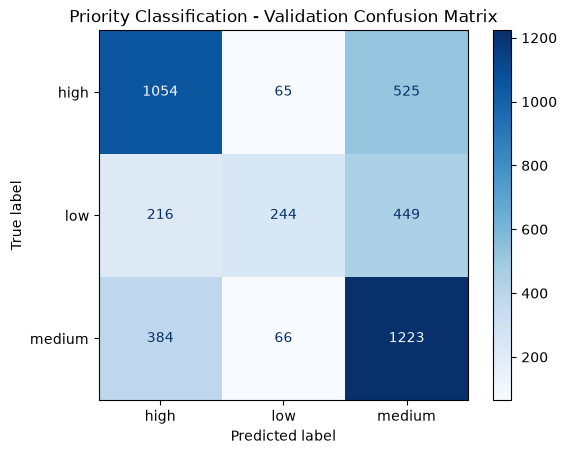

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_val_priority,
    y_val_priority_pred,
    cmap="Blues"
)

plt.title("Priority Classification - Validation Confusion Matrix")
plt.show()

### Priority Confusion Matrix Analysis

The confusion matrix shows that the Priority classifier has difficulty distinguishing both High and Low priority tickets from Medium priority tickets.

The largest error is the misclassification of Low-priority tickets as Medium, with 449 Low tickets predicted as Medium. Only 244 out of 909 actual Low-priority tickets were correctly classified, resulting in a recall of 0.27.

High-priority tickets were also frequently classified as Medium, with 525 such errors. Medium-priority tickets had the highest recall at 0.73, suggesting that the model tends to predict Medium when the text does not provide sufficiently distinctive signals for High or Low priority.

This indicates that priority classification is more challenging than ticket type classification using TF-IDF features alone. Unlike ticket type, priority may depend on contextual factors such as business impact, urgency, and scope of the issue, which may not always be explicitly expressed in the ticket text.

In [43]:
low_as_medium = val_df[
    (y_val_priority == "low") &
    (y_val_priority_pred == "medium")
].copy()

low_as_medium["predicted_priority"] = y_val_priority_pred[
    low_as_medium.index
]

print("Low → Medium errors:", len(low_as_medium))

low_as_medium[
    ["subject", "priority", "predicted_priority", "type", "queue"]
].head(20)

Low → Medium errors: 449


,subject,priority,predicted_priority,type,queue
47,Adherence to Security Regulations,low,medium,Change,Product Support
50,Service Revision,low,medium,Change,Customer Service
51,Interdepartmental Coordination Difficulties,low,medium,Incident,Customer Service
52,Problem with Agile Team Collaboration Tools,low,medium,Incident,Product Support
55,Subscription Billing Concern,low,medium,Incident,Billing and Payments
73,Excel Formula Computation Issues,low,medium,Problem,Technical Support
96,Assistance with Software Synchronization Problems,low,medium,Incident,Technical Support
99,Hospital System Security Concerns,low,medium,Incident,Technical Support
100,NaN,low,medium,Incident,Returns and Exchanges
101,Request for Customer Support,low,medium,Request,Customer Service


In [44]:
sample_low_as_medium = low_as_medium[
    ["subject", "body", "clean_text", "priority", "predicted_priority", "type"]
].head(10)

for idx, row in sample_low_as_medium.iterrows():
    print("\n" + "=" * 80)
    print(f"Ticket index: {idx}")
    print(f"Subject: {row['subject']}")
    print(f"Actual priority: {row['priority']}")
    print(f"Predicted priority: {row['predicted_priority']}")
    print(f"Type: {row['type']}")
    print("\nFull cleaned text:")
    print(row["clean_text"])


Ticket index: 47
Subject: Adherence to Security Regulations
Actual priority: low
Predicted priority: medium
Type: Change

Full cleaned text:
adherence to security regulations dear customer support team, i trust this message reaches you well. i am formally requesting an update on the security measures and compliance protocols implemented for the integrated devices utilized within telemedicine emr/pacs systems. these devices encompass microphones, laptops, internet of things (iot) gadgets, and data storage components. considering the sensitive nature of patient information managed by these platforms, it is crucial that security frameworks conform to the latest regulatory requirements, notably hipaa, gdpr, and other relevant standards.

Ticket index: 50
Subject: Service Revision
Actual priority: low
Predicted priority: medium
Type: Change

Full cleaned text:
service revision dear customer support team, i hope this message reaches you well. i am writing to request an update to the marketi

In [45]:
y_test_priority_pred = model_priority.predict(X_test_priority_tfidf)

priority_test_accuracy = accuracy_score(
    y_test_priority,
    y_test_priority_pred
)

print(f"Test Accuracy: {priority_test_accuracy:.4f}")
print(f"Test Accuracy: {priority_test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test_priority,
    y_test_priority_pred
))

Test Accuracy: 0.6128
Test Accuracy: 61.28%

Classification Report:
              precision    recall  f1-score   support

        high       0.66      0.67      0.66      1749
         low       0.61      0.28      0.38       809
      medium       0.57      0.72      0.64      1709

    accuracy                           0.61      4267
   macro avg       0.61      0.55      0.56      4267
weighted avg       0.62      0.61      0.60      4267



### Priority Model — Final Test Evaluation

The TF-IDF + Logistic Regression baseline achieved 61.28% accuracy on the held-out test set, compared with 59.65% on the validation set.

The model performed best on High and Medium priority tickets, with F1-scores of 0.66 and 0.64 respectively. However, performance on Low-priority tickets was substantially weaker, with a recall of only 0.28 and an F1-score of 0.38.

The confusion matrix showed that Low-priority tickets were frequently classified as Medium. This suggests that ticket text alone does not always provide sufficiently distinctive signals for determining priority. Priority can depend on factors such as urgency, business impact, affected scope, and context, which may not be explicitly expressed in the ticket text.

The small difference between validation and test performance suggests that the model generalizes reasonably well and does not show obvious signs of overfitting.